# 04 - The cost-sensitive decision layer

*This notebook is a thin view: it renders artifacts persisted by the pipeline (`make data features train evaluate figures`). No result is computed here.*

In [1]:
import json, sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import pandas as pd
from IPython.display import Image, display

RESULTS = Path.cwd().parent / "results" / "metrics"
FIGURES = Path.cwd().parent / "reports" / "figures"

def load(name):
    with open(RESULTS / f"{name}.json") as fh:
        return json.load(fh)

def fig(name):
    display(Image(str(FIGURES / f"{name}.png"), width=880))


Decline iff `p > k/(1+k)` (Elkan 2001): with FN cost = amount and FP cost = k x amount, expected cost of declining beats approving exactly when `p*A > (1-p)*k*A`. Amount cancels -- the threshold is amount-independent, but only meaningful on calibrated p.

In [2]:
pol = load('stage4_policies_test')
tbl = pd.DataFrame({k: v for k, v in pol['policy_table_test'].items() if not k.startswith('_')}).T
tbl[['total_cost','savings','fraud_dollars_caught','legit_dollars_declined','tpr','fpr']].round(4)

,total_cost,savings,fraud_dollars_caught,legit_dollars_declined,tpr,fpr
approve_all,4.952444e+05,0.0000,0.0000,0.000000e+00,0.0000,0.0000
decline_all,1.872497e+06,-2.7810,495244.3967,1.248332e+07,1.0000,1.0000
f1_opt,3.396754e+05,0.3141,171157.1801,1.039210e+05,0.4388,0.0067
youden,3.595825e+05,0.2739,367604.6611,1.546285e+06,0.7483,0.0891
cost_uncal,3.114034e+05,0.3712,221429.6951,2.505911e+05,0.5213,0.0151
cost_cal,3.002712e+05,0.3937,274003.0951,5.268663e+05,0.6039,0.0291


In [3]:
pd.DataFrame(pol['bootstrap_ci']).T.round(4)

,lo,hi,se
savings_approve_all,0.0000,0.0000,0.0000
savings_decline_all,-3.0478,-2.5425,0.1331
savings_f1_opt,0.2846,0.3453,0.0157
savings_youden,0.2285,0.3200,0.0232
savings_cost_uncal,0.3392,0.4041,0.0168
savings_cost_cal,0.3576,0.4281,0.0184
tpr_at_5fpr,0.6552,0.6876,0.0082
pr_auc,0.5474,0.5814,0.0087
roc_auc,0.8975,0.9102,0.0033


In [4]:
pol['calibration_dollar_gap']

{'cost_uncal_minus_cost_cal': 11132.124323934317,
 'as_pct_of_baseline': 0.022478041948118938}

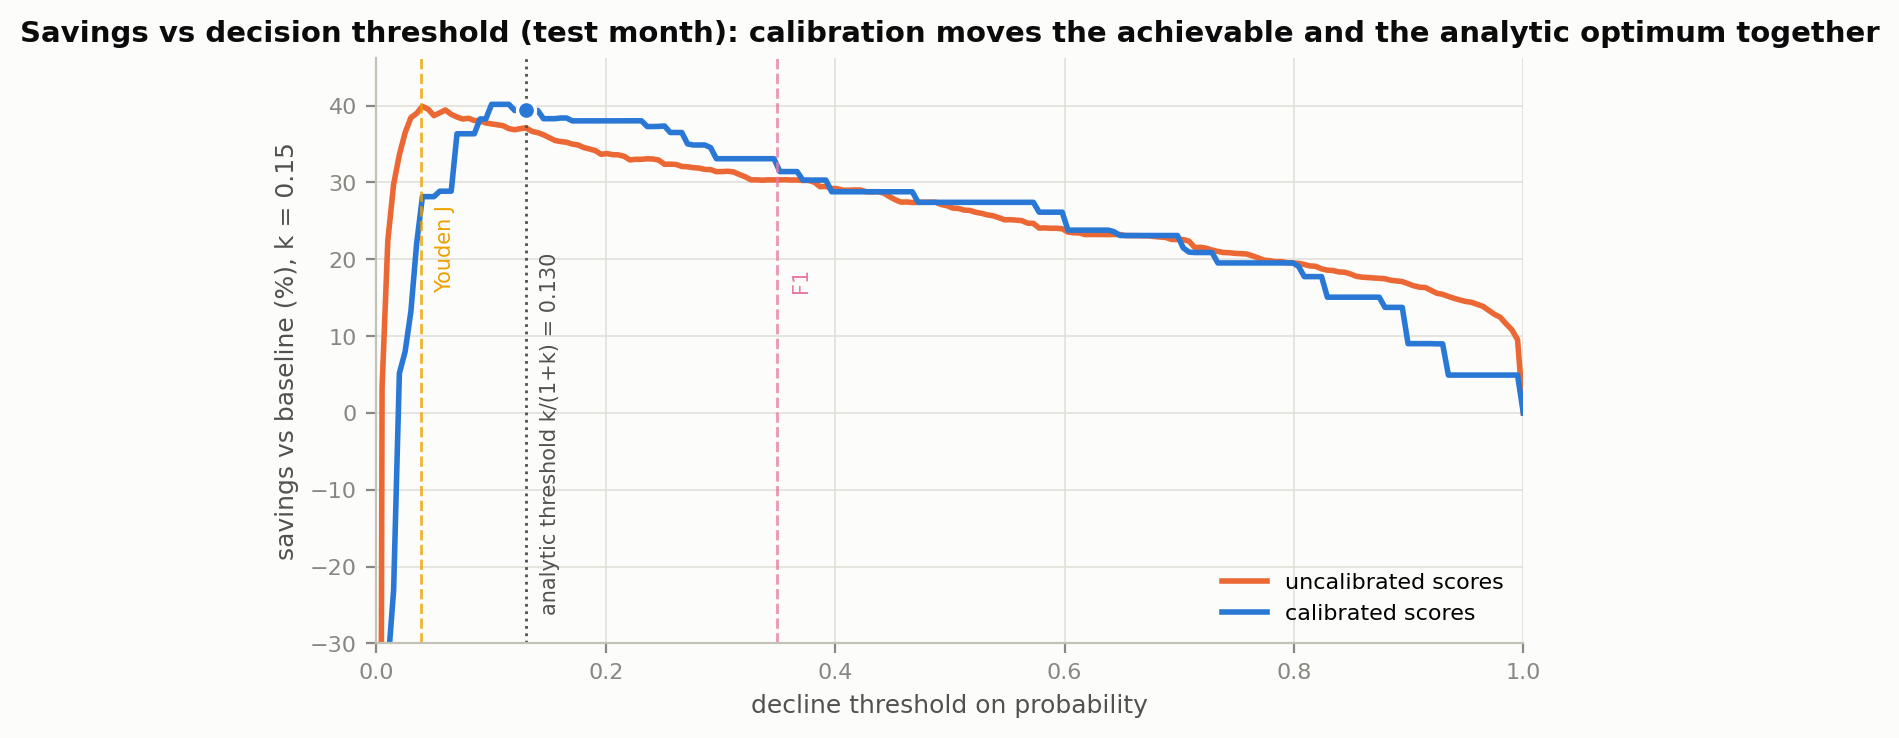

In [5]:
fig('figure_05_cost_vs_threshold')

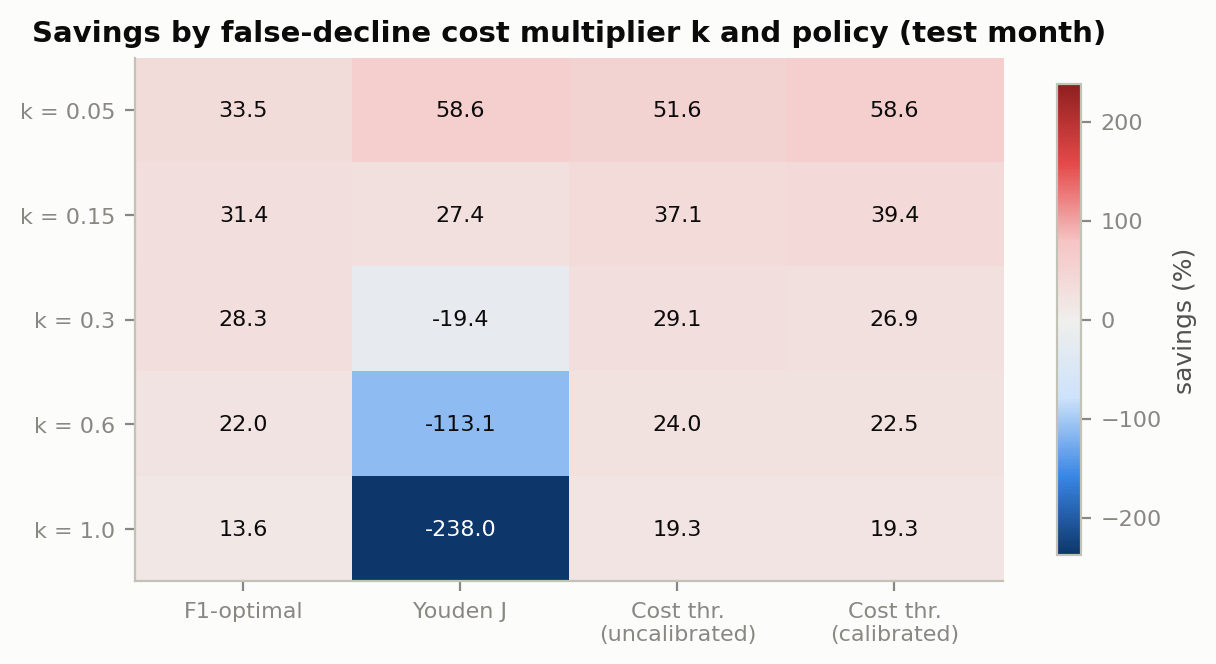

In [6]:
fig('figure_06_sensitivity_heatmap')